In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from collections import Counter, defaultdict, deque
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Video, display

In [3]:
DAY_02_DIR = Path(
    "/content/drive/MyDrive/Vision/vision_unit_03/outputs/day_02"
)

TRACKING_VIDEO_PATH = DAY_02_DIR / "bytetrack_baseline.mp4"
TRACKS_CSV_PATH = DAY_02_DIR / "tracks.csv"

DAY_03_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Vision/vision_unit_03/outputs/day_03"
)
DAY_03_OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

EVENTS_CSV_PATH = DAY_03_OUTPUT_DIR / "counting_events.csv"
COUNTING_VIDEO_PATH = DAY_03_OUTPUT_DIR / "traffic_counting.mp4"

In [4]:
tracks_df = pd.read_csv(TRACKS_CSV_PATH)

required_columns = {
    "frame_index",
    "timestamp_seconds",
    "track_id",
    "class_name",
    "confidence",
    "x1",
    "y1",
    "x2",
    "y2",
}

missing_columns = required_columns - set(tracks_df.columns)

capture = cv2.VideoCapture(str(TRACKING_VIDEO_PATH))

width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

source_fps = float(capture.get(cv2.CAP_PROP_FPS))
reported_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

capture.release()

metadata_df = pd.DataFrame(
    [
        {
            "width": width,
            "height": height,
            "source_fps": source_fps,
            "reported_frames": reported_frames,
            "track_rows": len(tracks_df),
            "unique_track_ids": (
                tracks_df["track_id"].nunique()
            ),
        }
    ]
)

display(metadata_df)

,width,height,source_fps,reported_frames,track_rows,unique_track_ids
0,768,432,12.0,647,306,10


**Counting line preview**

In [6]:
LINE_Y_RATIO = 0.58

line_y = int(round(height * LINE_Y_RATIO))

LINE_START = (0, line_y)
LINE_END = (width - 1, line_y)

PREVIEW_FRAME_INDEX = 213

capture = cv2.VideoCapture(str(TRACKING_VIDEO_PATH))
capture.set(cv2.CAP_PROP_POS_FRAMES, PREVIEW_FRAME_INDEX)

success, preview_frame = capture.read()
capture.release()

cv2.line(
    preview_frame, LINE_START, LINE_END,
    (0, 0, 255), 3, cv2.LINE_AA
)

preview_rgb = cv2.cvtColor(
    preview_frame, cv2.COLOR_BGR2RGB
)

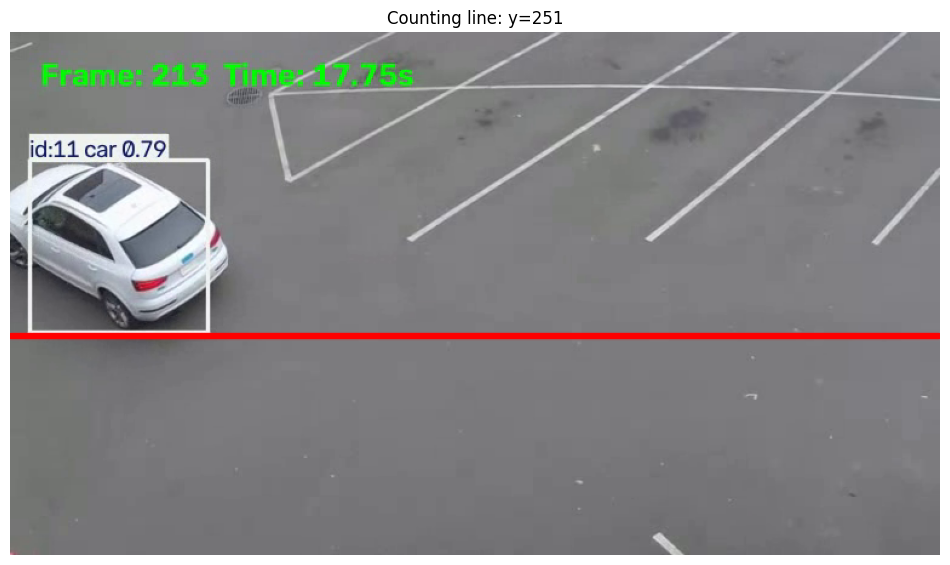

LINE_START: (0, 251)
LINE_END: (767, 251)


In [7]:
plt.figure(figsize=(12, 7))

plt.imshow(preview_rgb)
plt.title(f"Counting line: y={line_y}")
plt.axis("off")
plt.show()

print("LINE_START:", LINE_START)
print("LINE_END:", LINE_END)

### Crossing detection

**Side, crossing and direction**

In [8]:
def bottom_center(row):
    center_x = (float(row.x1) + float(row.x2)) / 2.0
    bottom_y = float(row.y2)
    
    return center_x, bottom_y

def signed_line_side(point, line_start, line_end):
    point_x, point_y = point
    
    start_x, start_y = line_start
    end_x, end_y = line_end
    
    return (
        (end_x - start_x) * (point_y - start_y)
        -
        (end_y - start_y) * (point_x - start_x)
    )

In [9]:
def side_label(signed_value, epsilon=1e-6):
    if signed_value > epsilon:
        return 1
    if signed_value < -epsilon:
        return -1
    
    return 0


def dominant_class(series):
    modes = series.mode()

    if len(modes) > 0:
        return modes.iloc[0]

    return series.iloc[0]

In [10]:
dominant_class_by_id = (
    tracks_df.groupby("track_id")["class_name"]
    .agg(dominant_class)
    .to_dict()
)

In [12]:
ordered_tracks_df = (
    tracks_df.sort_values(
        ["frame_index", "track_id"]
    ).reset_index(drop=True)
)

track_state = {}
counted_track_ids = set()
counting_events = []

for row in ordered_tracks_df.itertuples(index=False):
    track_id = int(row.track_id)
    current_point = bottom_center(row)
    
    signed_value = signed_line_side(
        current_point, LINE_START, LINE_END
    )
    
    current_side = side_label(signed_value)
    
    if current_side == 0:
        continue
    
    previous_state = track_state.get(track_id)
    
    crossed = (
        previous_state is not None and
        previous_state["side"] != current_side
    )
    
    if crossed and track_id not in counted_track_ids:
        previous_point = previous_state["point"]
        
        direction = (
            "up" if current_point[1] < previous_point[1]
            else "down"
        )
        
        counting_events.append(
            {
                "frame_index": int(row.frame_index),
                "timestamp_seconds":float(row.timestamp_seconds),
                "track_id": track_id,
                "class_name": (
                    dominant_class_by_id[track_id]
                ),
                "direction": direction,
                "confidence": float(row.confidence),
                "crossing_x": float( current_point[0]),
                "crossing_y": float(current_point[1]),
                "previous_frame": previous_state["frame_index"]
            }
        )

        counted_track_ids.add(track_id)
    
    
    track_state[track_id] = {
        "point" : current_point,
        "side" : current_side,
        "frame_index" : int(row.frame_index)
    }

In [13]:
events_df = pd.DataFrame(counting_events)

if not events_df.empty:
    events_df.insert(0, "event_id", range(1, len(events_df) + 1))

events_df.to_csv(EVENTS_CSV_PATH, index=False)

display(events_df.round(3))

,event_id,frame_index,timestamp_seconds,track_id,class_name,direction,confidence,crossing_x,crossing_y,previous_frame
0,1,62,5.167,1,person,up,0.859,677.901,245.978,61
1,2,213,17.750,11,car,up,0.788,89.947,248.212,212
2,3,562,46.833,36,car,up,0.779,199.474,247.599,561


In [ ]:
if not events_df.empty:
    event_summary_df = pd.crosstab(
        events_df["class_name"],
        events_df["direction"],
        margins=True,
    )

    display(event_summary_df)
else:
    print("No crossing events detected")

direction,up,All
class_name,,
car,2,2
person,1,1
All,3,3


### Counting video

**Render counting video**

In [15]:
tracks_by_frame = {
    int(frame_index): (group.to_dict("records"))
    for frame_index, group in tracks_df.groupby(
    "frame_index"
    )
}

events_by_frame = {
    int(frame_index): (group.to_dict("records"))
    for frame_index, group in events_df.groupby(
        "frame_index"
    )
}

def track_color(track_id):
    track_id = int(track_id)
    
    return (
        70 + (37 * track_id) % 185,
        70 + (17 * track_id) % 185,
        70 + (29 * track_id) % 185
    )

In [16]:
capture = cv2.VideoCapture(str(TRACKING_VIDEO_PATH))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(COUNTING_VIDEO_PATH),
    fourcc, source_fps, (width, height)
)

In [ ]:
TRAJECTORY_LENGTH = 30
STALE_HISTORY_FRAMES = 60

track_history = defaultdict(
    lambda: deque(maxlen=TRAJECTORY_LENGTH)
)

last_seen_frame = {}
direction_counts = Counter()
class_counts = Counter()
processed_frames = 0


try:
    while True:
        success, frame = capture.read()
        if not success:
            break

        frame_index = processed_frames
        current_tracks = tracks_by_frame.get(frame_index, [])
        

        for track in current_tracks:
            track_id = int(track["track_id"])

            point = (
                int(
                    round(
                        (track["x1"] + track["x2"]) / 2.0
                    )
                ),
                int(round(track["y2"])),
            )

            track_history[track_id].append(point)
            last_seen_frame[track_id] = frame_index


        stale_track_ids = [
            track_id
            for track_id, last_frame in last_seen_frame.items()
            if (
                frame_index - last_frame > STALE_HISTORY_FRAMES
            )
        ]

        for track_id in stale_track_ids:
            track_history.pop(track_id, None)
            last_seen_frame.pop(track_id, None)


        for (track_id, history) in track_history.items():
            if len(history) < 2:
                continue

            trajectory = np.array(
                list(history), dtype=np.int32,
            ).reshape(-1, 1, 2)

            cv2.polylines(
                frame, [trajectory],
                isClosed=False,
                color=track_color(track_id),
                thickness=2, lineType=cv2.LINE_AA
            )

        current_events = events_by_frame.get(frame_index, [])
        
        for event in current_events:
            direction_counts[event["direction"]] += 1
            class_counts[event["class_name"]] += 1


        line_color = (
            (0, 255, 255)
            if not current_events
            else (0, 0, 255)
        )

        cv2.line(
            frame,
            LINE_START, LINE_END,
            line_color, 3, cv2.LINE_AA
        )
        
        cv2.rectangle(
            frame,(0, 0), 
            (370, 140), (20, 20, 20), thickness=-1
        )

        total_count = sum(direction_counts.values())

        cv2.putText(
            frame,
            (
                f"Total crossings: "
                f"{total_count}"
            ),
            (15, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.75,
            (255, 255, 255), 2, cv2.LINE_AA,
        )

        cv2.putText(
            frame,
            (
                f"Up: "
                f"{direction_counts['up']}  "
                f"Down: "
                f"{direction_counts['down']}"
            ),
            (15, 60), cv2.FONT_HERSHEY_SIMPLEX,
            0.68, (255, 255, 255), 2,
            cv2.LINE_AA
        )

        class_text = (
            "  ".join(
                f"{name}: {count}"
                for name, count in sorted(class_counts.items())
            )
            or "No crossings yet"
        )

        cv2.putText(
            frame, class_text,
            (15, 90), cv2.FONT_HERSHEY_SIMPLEX,
            0.58, (255, 255, 255),
            1, cv2.LINE_AA,
        )

        cv2.putText(
            frame,
            (
                f"Frame: {frame_index}  "
                f"Line y: {line_y}"
            ),
            (15, 120), cv2.FONT_HERSHEY_SIMPLEX,
            0.55, (180, 255, 180),
            1, cv2.LINE_AA
        )

        if current_events:
            event = current_events[0]
            alert_text = (
                f"CROSS: ID {event['track_id']} "
                f"{event['class_name']} "
                f"{event['direction']}"
            )

            cv2.putText(
                frame, alert_text,
                (15, height - 25), cv2.FONT_HERSHEY_SIMPLEX,
                0.75, (0, 0, 255),
                2, cv2.LINE_AA
            )


        writer.write(frame)
        processed_frames += 1

finally:
    capture.release()
    writer.release()


print("Processed frames:",processed_frames)
print("Direction counts:",dict(direction_counts))
print("Class counts:",dict(class_counts))
print("Output:",COUNTING_VIDEO_PATH)

Processed frames: 647
Direction counts: {'up': 3}
Class counts: {'person': 1, 'car': 2}
Output: /content/drive/MyDrive/Vision/vision_unit_03/outputs/day_03/traffic_counting.mp4


In [ ]:
output_capture = cv2.VideoCapture(str(COUNTING_VIDEO_PATH))
output_opened = output_capture.isOpened()


output_width = int(output_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
output_height = int(output_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_fps = float(output_capture.get(cv2.CAP_PROP_FPS))
output_frames = int(output_capture.get(cv2.CAP_PROP_FRAME_COUNT))

first_frame_ok, _ = output_capture.read()
output_capture.release()


completion_checks = {
    "all_frames_processed": (
        processed_frames == reported_frames
    ),
    "output_video_exists": (
        COUNTING_VIDEO_PATH.exists()
    ),
    "output_video_opens": (
        output_opened
    ),
    "first_frame_reads": (
        first_frame_ok
    ),
    "frame_count_matches": (
        output_frames == processed_frames
    ),
    "resolution_matches": (
        output_width == width
        and output_height == height
    ),
    "fps_matches": (
        abs(output_fps - source_fps) < 0.1
    ),
    "events_csv_exists": (
        EVENTS_CSV_PATH.exists()
    ),
    "events_found": (
        len(events_df) > 0
    ),
    "no_track_counted_twice": (
        events_df["track_id"].is_unique
    ),
    "rendered_count_matches_events": (
        sum(direction_counts.values())
        == len(events_df)
    )
}


completion_df = pd.DataFrame(
    completion_checks.items(),
    columns=["check", "passed"]
)

display(completion_df)

,check,passed
0,all_frames_processed,True
1,output_video_exists,True
2,output_video_opens,True
3,first_frame_reads,True
4,frame_count_matches,True
5,resolution_matches,True
6,fps_matches,True
7,events_csv_exists,True
8,events_found,True
9,no_track_counted_twice,True
